In [3]:
# iMPORT LIBRARY
!pip install --upgrade scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
#Load Dataset
df = pd.read_csv('/content/customer_churn_business_dataset.csv')

In [5]:
# EDA
df

,customer_id,gender,age,country,city,customer_segment,tenure_months,signup_channel,contract_type,monthly_logins,...,avg_resolution_time,complaint_type,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,survey_response,referral_count,churn
0,CUST_00001,Male,68,Bangladesh,London,SME,22,Web,Monthly,26,...,13.354360,Service,4.0,0,0.71,0.40,27,Satisfied,1,0
1,CUST_00002,Female,57,Canada,Sydney,Individual,9,Mobile,Monthly,7,...,25.140088,Billing,2.0,0,0.78,0.33,-19,Neutral,2,1
2,CUST_00003,Male,24,Germany,New York,SME,58,Web,Yearly,19,...,27.572928,Service,3.0,0,0.35,0.49,80,Neutral,1,0
3,CUST_00004,Male,49,Australia,Dhaka,Individual,19,Mobile,Yearly,34,...,26.420822,Technical,5.0,1,0.83,0.15,100,Neutral,0,0
4,CUST_00005,Male,65,Bangladesh,Delhi,Individual,52,Web,Monthly,20,...,26.674579,Technical,4.0,0,0.65,0.44,21,Unsatisfied,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,CUST_09996,Female,67,Germany,Sydney,SME,37,Web,Yearly,15,...,34.240174,Service,4.0,1,0.36,0.28,20,Satisfied,2,0
9996,CUST_09997,Male,26,USA,Toronto,Individual,42,Mobile,Yearly,13,...,40.092087,NaN,4.0,0,0.48,0.06,28,Unsatisfied,2,0
9997,CUST_09998,Female,18,Canada,Sydney,Individual,39,Mobile,Yearly,15,...,25.215810,Technical,1.0,0,0.11,0.07,-30,Satisfied,1,0
9998,CUST_09999,Female,30,USA,Delhi,Individual,52,Web,Monthly,14,...,20.544921,NaN,2.0,0,0.25,0.31,58,Neutral,1,1


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 32 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             10000 non-null  object 
 1   gender                  10000 non-null  object 
 2   age                     10000 non-null  int64  
 3   country                 10000 non-null  object 
 4   city                    10000 non-null  object 
 5   customer_segment        10000 non-null  object 
 6   tenure_months           10000 non-null  int64  
 7   signup_channel          10000 non-null  object 
 8   contract_type           10000 non-null  object 
 9   monthly_logins          10000 non-null  int64  
 10  weekly_active_days      10000 non-null  int64  
 11  avg_session_time        10000 non-null  float64
 12  features_used           10000 non-null  int64  
 13  usage_growth_rate       10000 non-null  float64
 14  last_login_days_ago     10000 non-null 

In [10]:
df.describe()

,age,tenure_months,monthly_logins,weekly_active_days,avg_session_time,features_used,usage_growth_rate,last_login_days_ago,monthly_fee,total_revenue,payment_failures,support_tickets,avg_resolution_time,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,referral_count,churn
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.0000,10000.000000
mean,45.906100,30.155700,19.672000,3.479400,15.187890,4.990800,0.019423,9.505200,34.930000,1057.018000,0.501000,1.206600,23.953210,3.486700,0.294100,0.499610,0.253575,19.110500,0.9922,0.102100
std,16.420416,17.099517,9.838003,2.302283,6.830774,2.211607,0.149567,9.799417,23.785115,1020.148233,0.711934,1.104554,9.956999,0.978631,0.543171,0.231601,0.140532,38.936619,0.9939,0.302795
min,18.000000,1.000000,0.000000,0.000000,1.000000,1.000000,-0.580000,0.000000,10.000000,10.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.100000,0.010000,-100.000000,0.0000,0.000000
25%,32.000000,16.000000,13.000000,1.000000,10.391645,3.000000,-0.080000,2.000000,20.000000,340.000000,0.000000,0.000000,17.082041,3.000000,0.000000,0.300000,0.130000,-7.000000,0.0000,0.000000
50%,46.000000,30.000000,20.000000,3.000000,15.161659,5.000000,0.020000,6.000000,30.000000,720.000000,0.000000,1.000000,23.950444,4.000000,0.000000,0.500000,0.250000,19.000000,1.0000,0.000000
75%,60.000000,45.000000,26.000000,5.000000,19.882034,6.000000,0.120000,13.000000,50.000000,1440.000000,1.000000,2.000000,30.758480,4.000000,1.000000,0.700000,0.380000,46.000000,2.0000,0.000000
max,74.000000,59.000000,54.000000,7.000000,41.996411,15.000000,0.540000,80.000000,100.000000,5900.000000,5.000000,7.000000,61.821878,5.000000,4.000000,0.900000,0.500000,100.000000,7.0000,1.000000


In [11]:
# Cek Missing Value
df.isnull().sum()

,0
customer_id,0
gender,0
age,0
country,0
city,0
customer_segment,0
tenure_months,0
signup_channel,0
contract_type,0
monthly_logins,0


In [12]:
df.duplicated().sum()

np.int64(0)

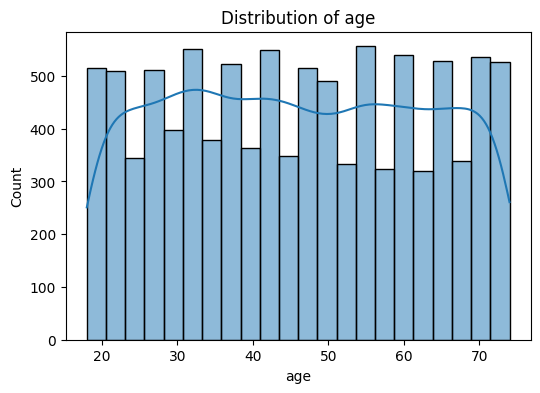

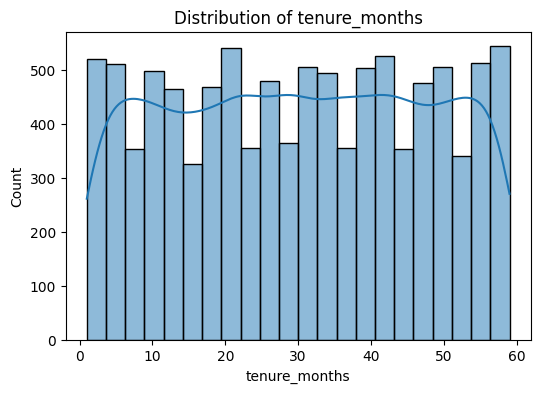

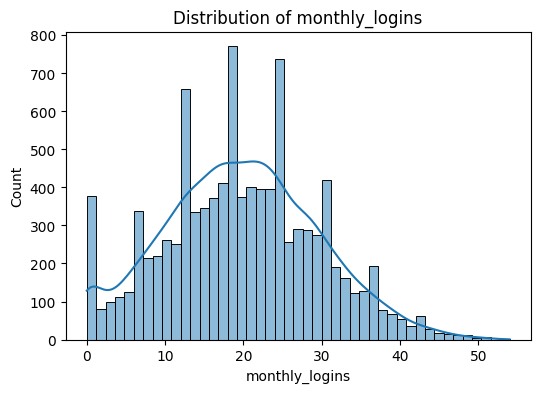

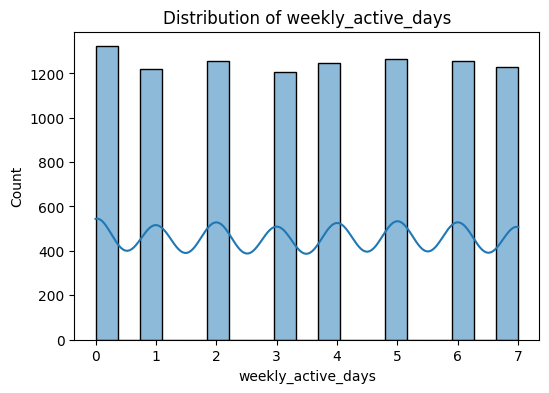

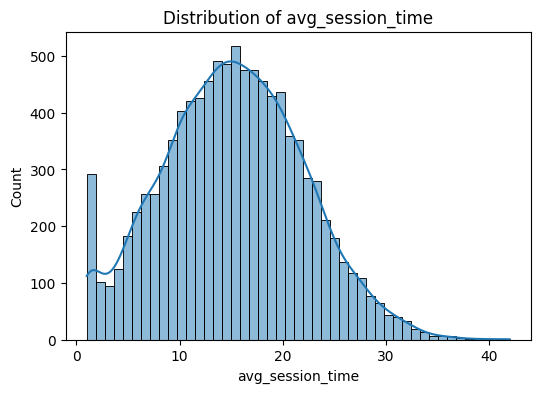

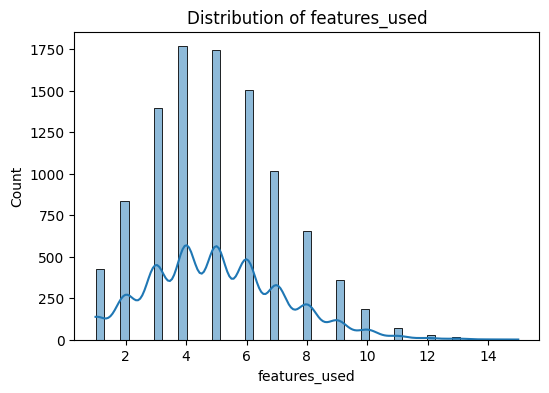

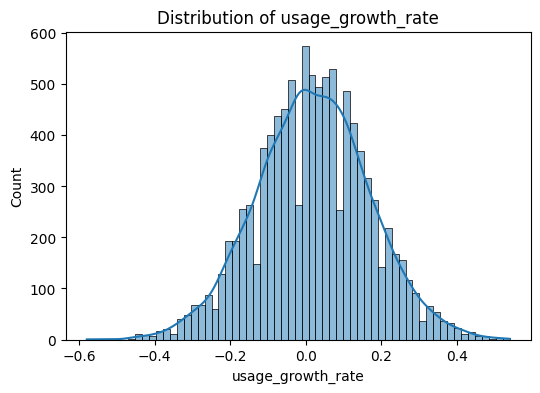

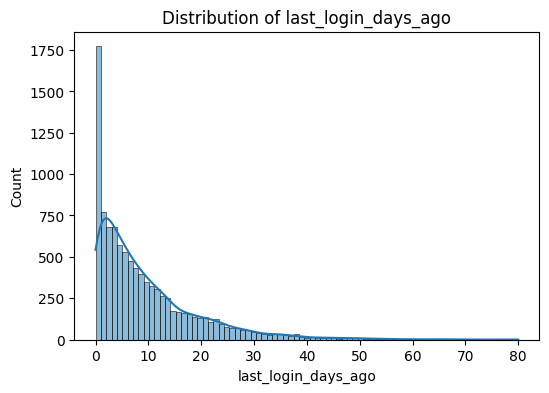

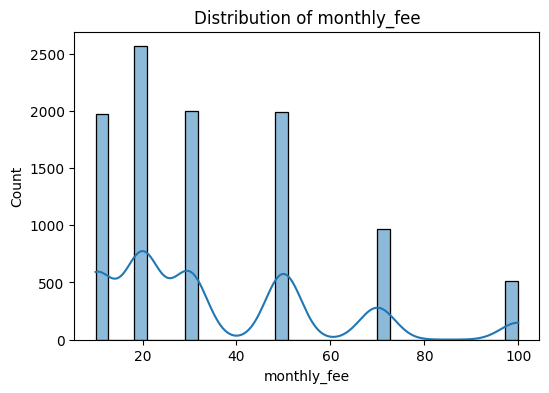

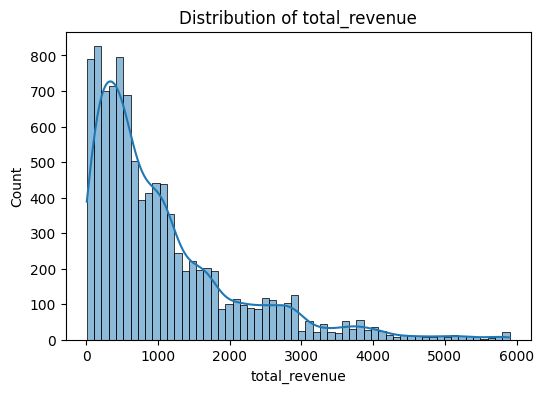

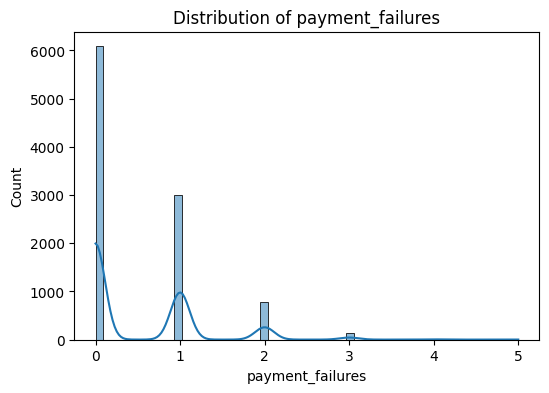

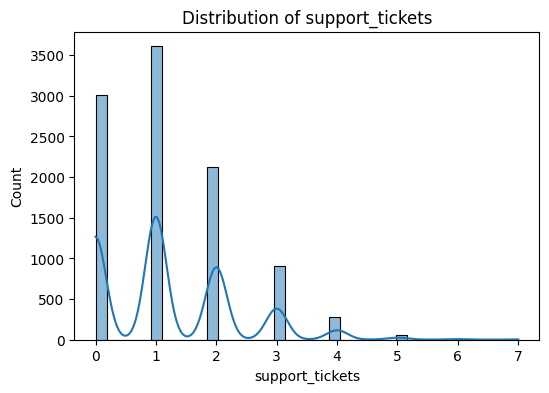

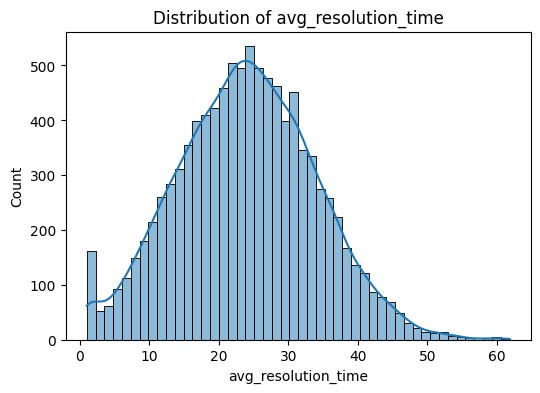

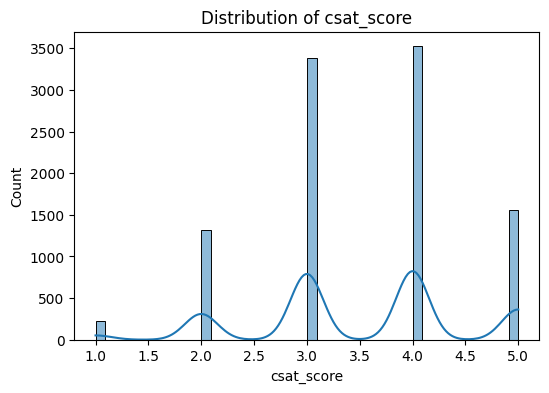

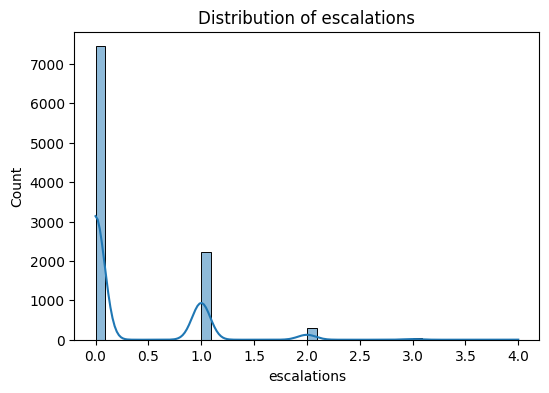

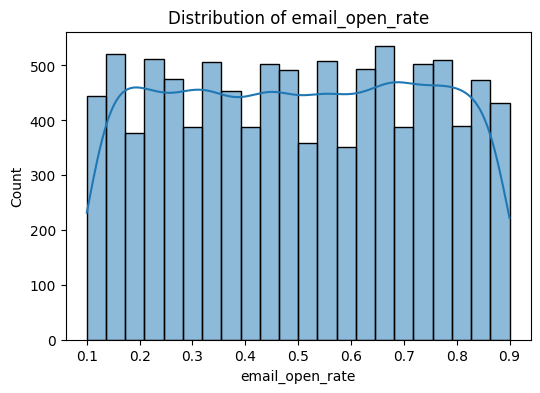

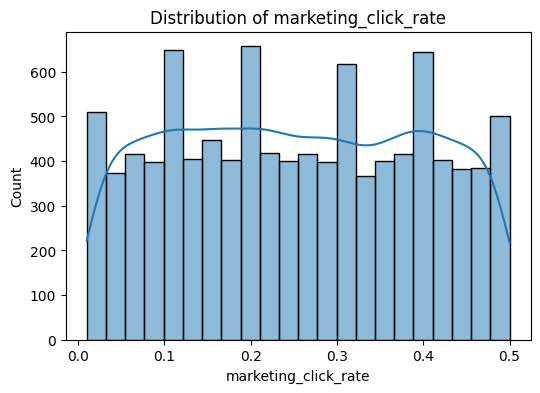

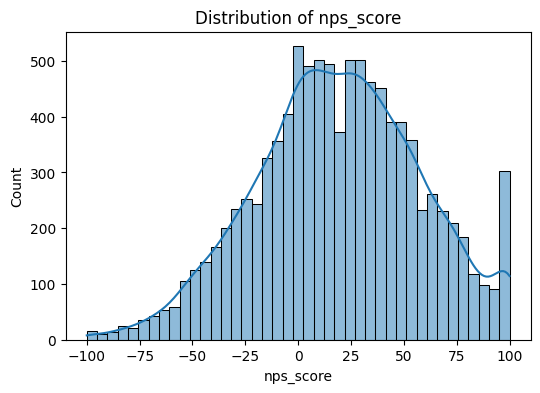

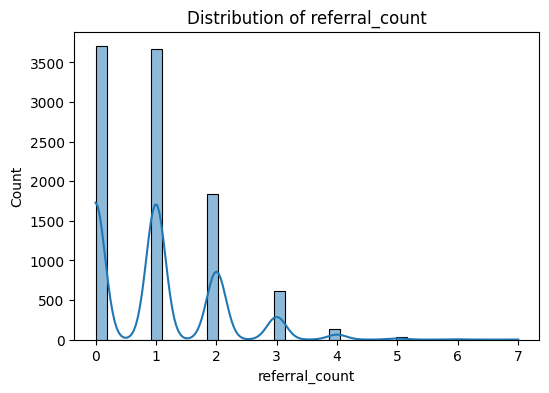

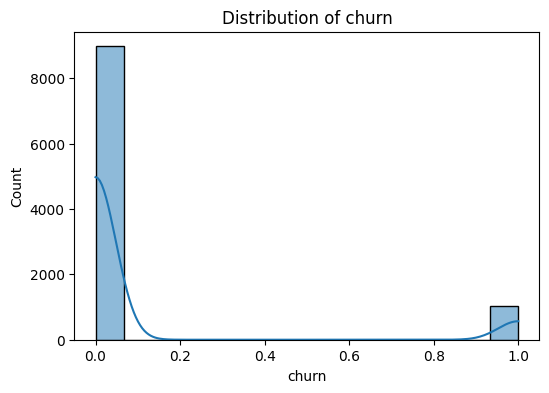

In [16]:
# Cek Sebaran Data

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

In [18]:
# Handling Missing Value
df['complaint_type'] = df['complaint_type'].fillna(df['complaint_type'].mode()[0])


In [20]:
#Cek Missing Value
df.isnull().sum()

,0
customer_id,0
gender,0
age,0
country,0
city,0
customer_segment,0
tenure_months,0
signup_channel,0
contract_type,0
monthly_logins,0


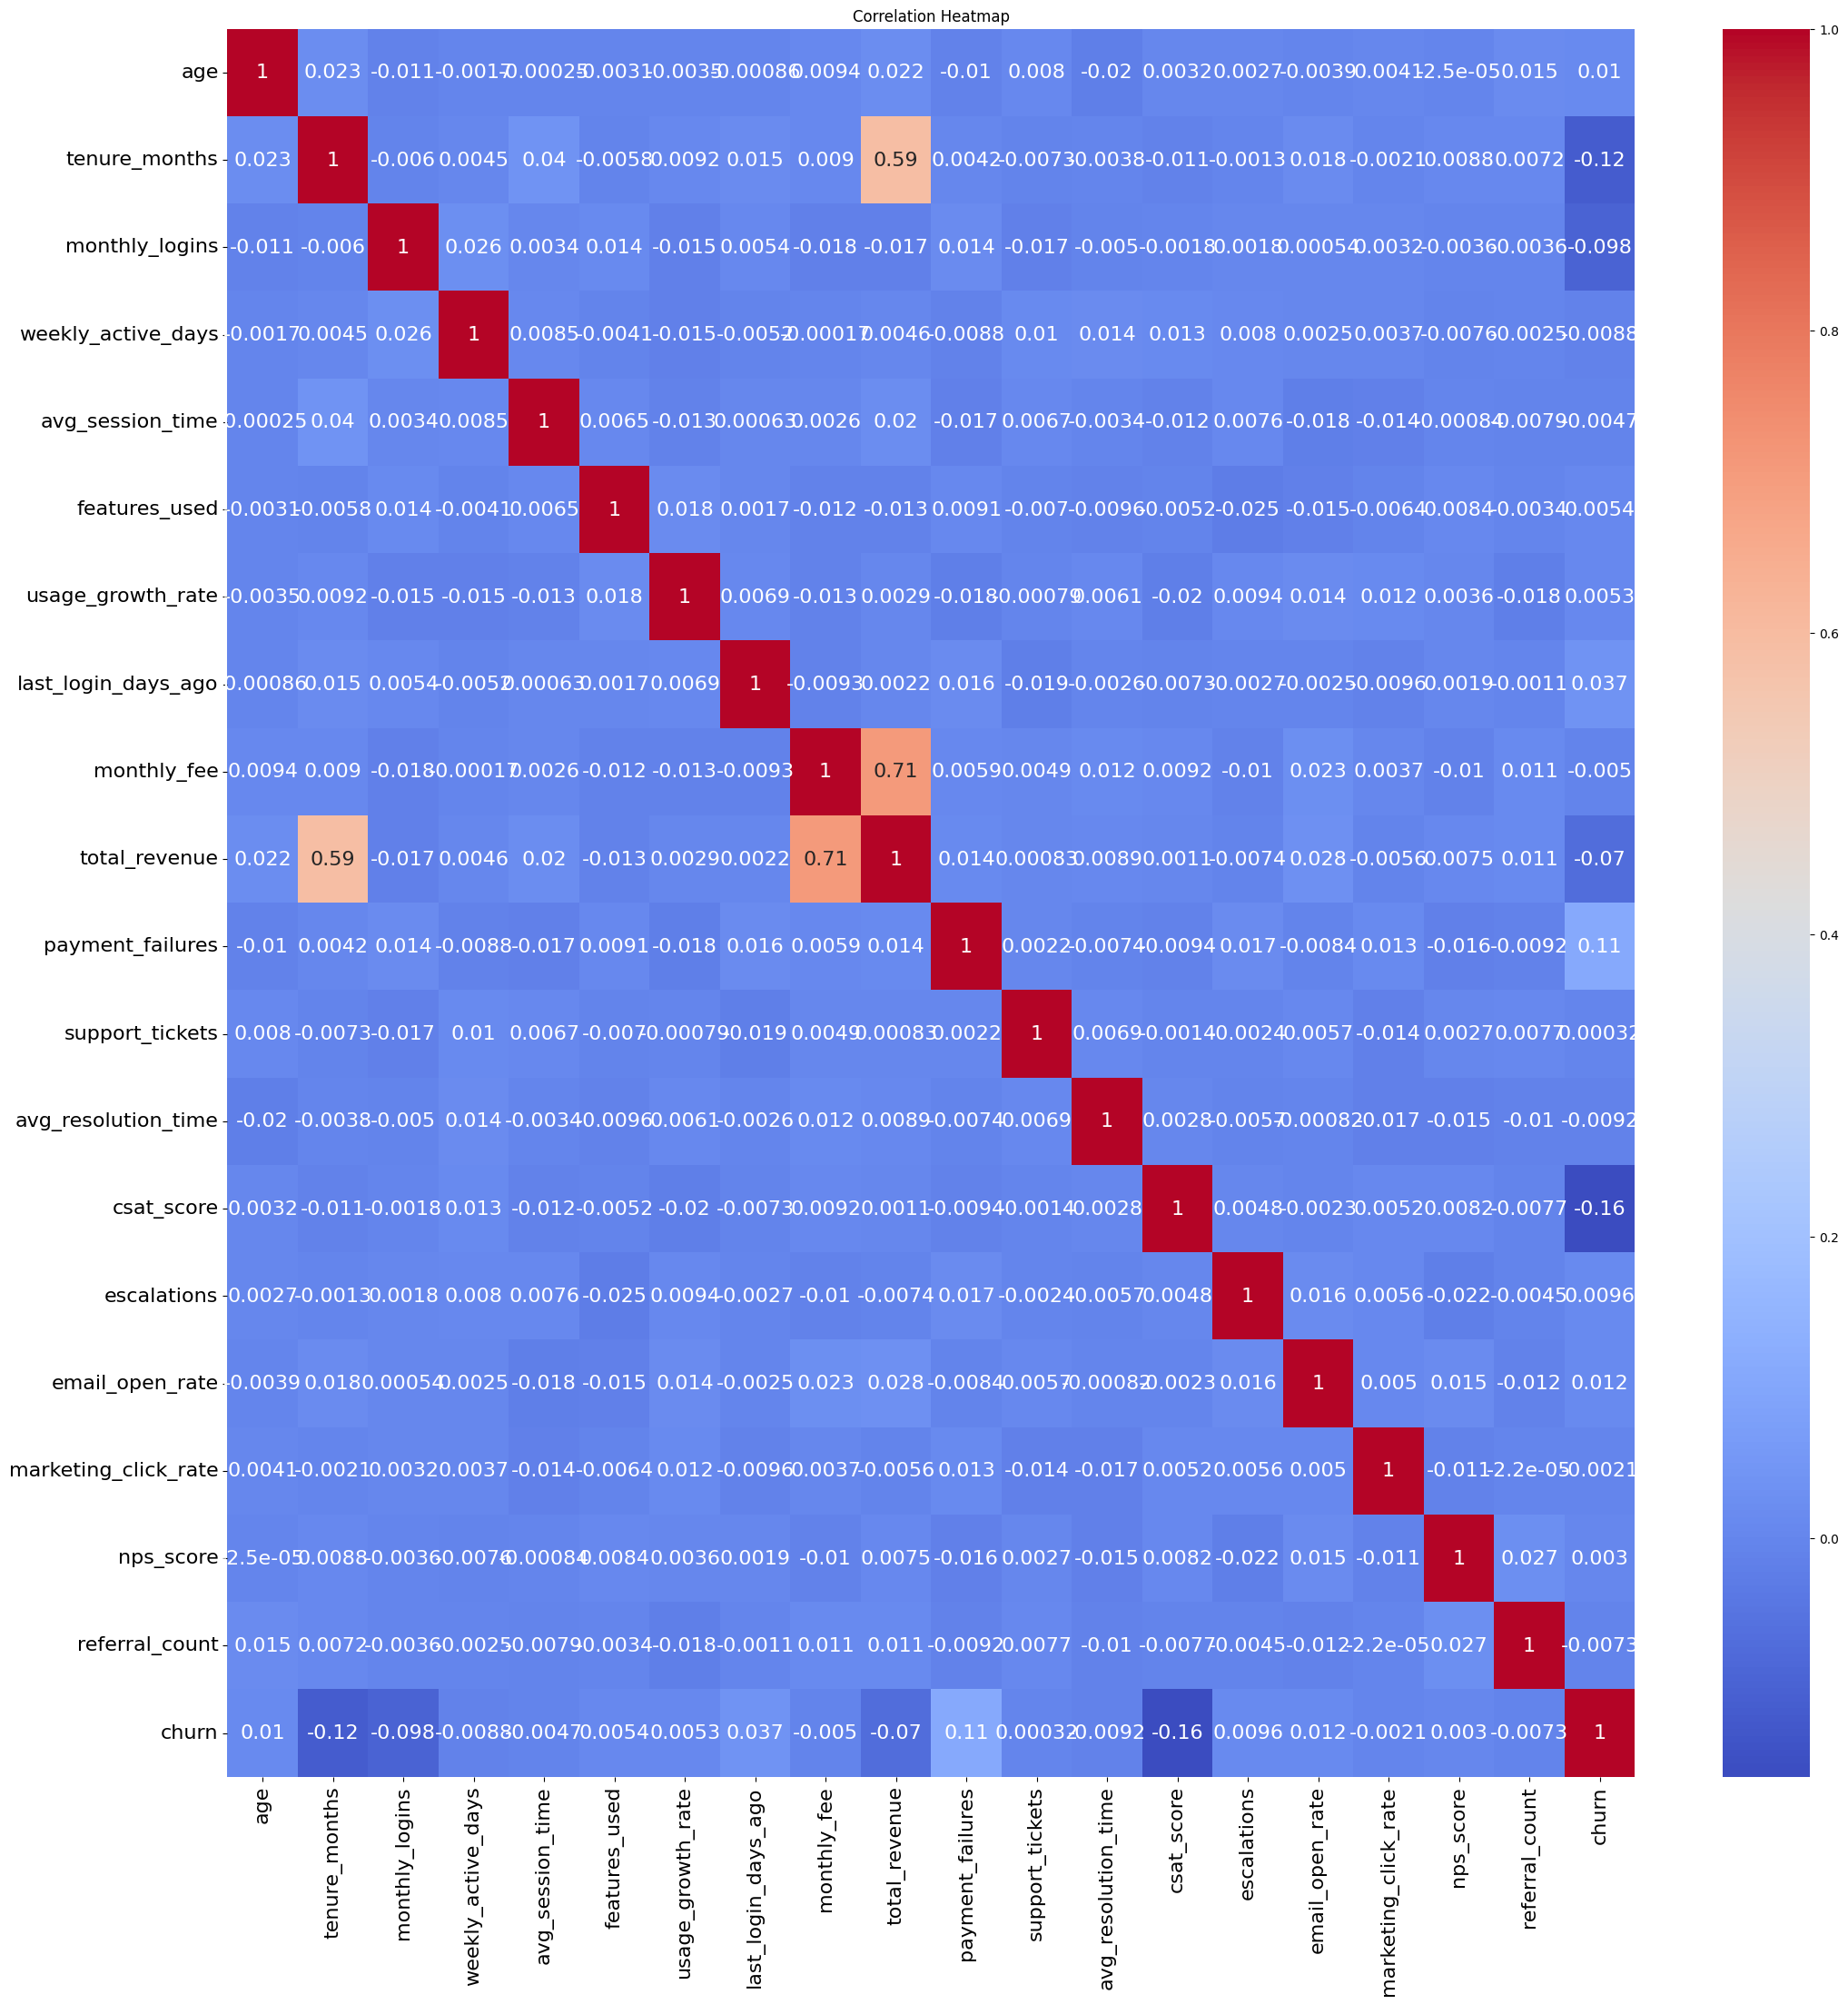

In [22]:
#Cek Korelasi

corr = df[numerical_cols].corr()
plt.figure(figsize=(25,25))
sns.heatmap(corr, annot=True, cmap="coolwarm", annot_kws={"size" : 16})
plt.title('Correlation Heatmap')
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.show()

In [23]:
#Handling inconsistent Data

df["customer_id"] = df["customer_id"].str.upper()
df["customer_id"] = df["customer_id"].str.strip()

df["gender"] = df["gender"].str.lower()
df["gender"] = df["gender"].str.strip()

df["country"] = df["country"].str.lower()
df["country"] = df["country"].str.strip()

df["customer_segment"] = df["customer_segment"].str.lower()
df["customer_segment"] = df["customer_segment"].str.strip()

df["city"] = df["city"].str.lower()
df["city"] = df["city"].str.strip()

df["contract_type"] = df["contract_type"].str.lower()
df["contract_type"] = df["contract_type"].str.strip()

df["signup_channel"] = df["signup_channel"].str.lower()
df["signup_channel"] = df["signup_channel"].str.strip()

df["complaint_type"] = df["complaint_type"].str.lower()
df["complaint_type"] = df["complaint_type"].str.strip()

df["survey_response"] = df["survey_response"].str.lower()
df["survey_response"] = df["survey_response"].str.strip()


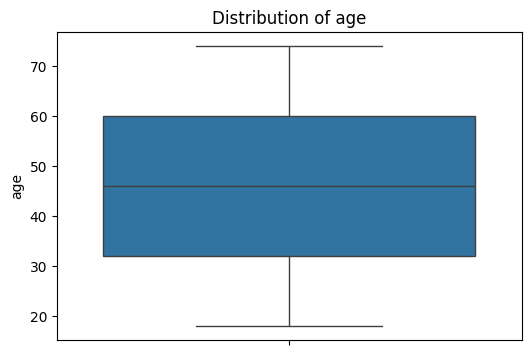

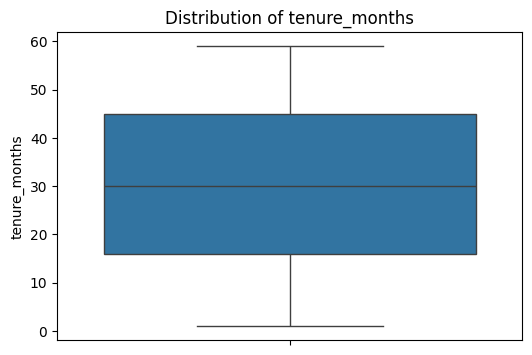

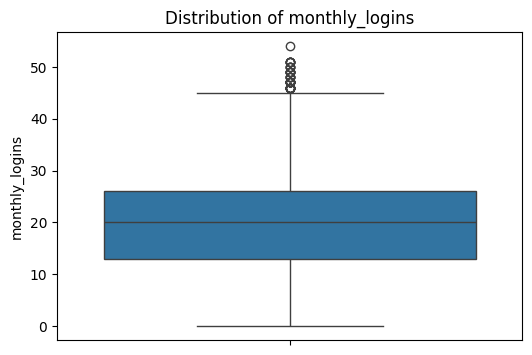

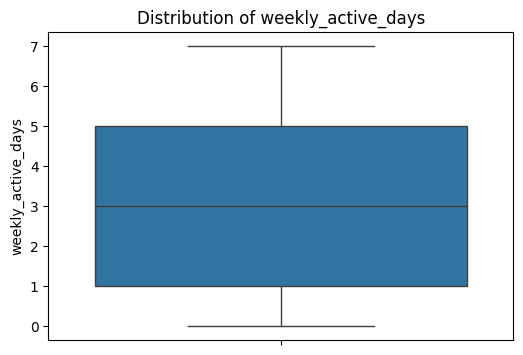

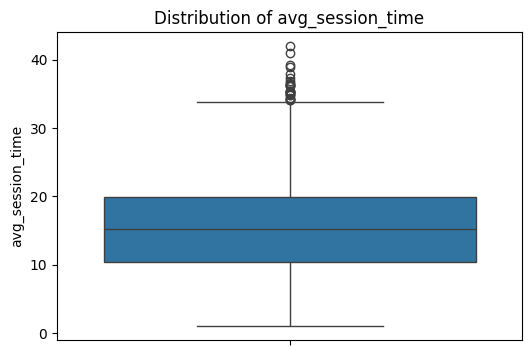

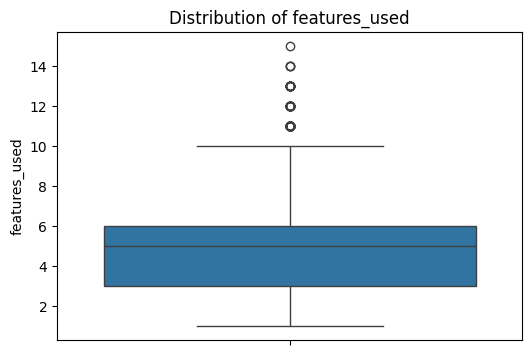

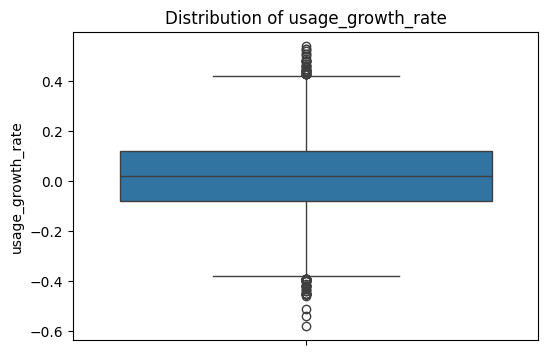

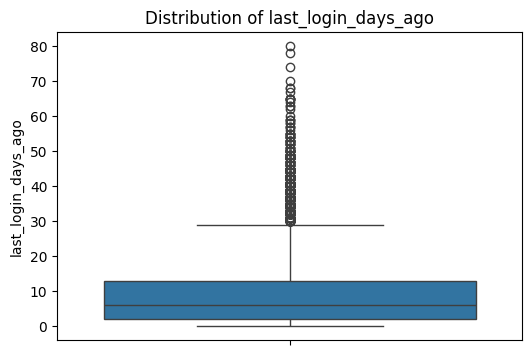

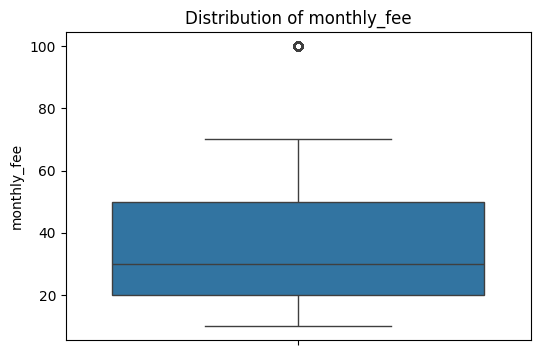

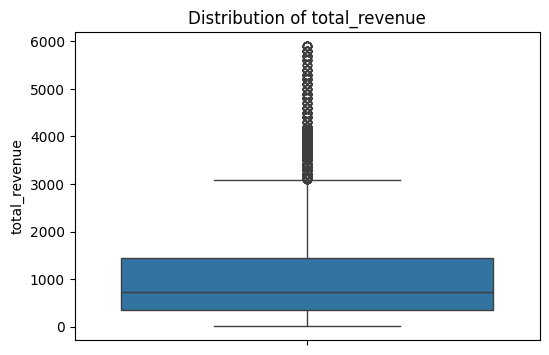

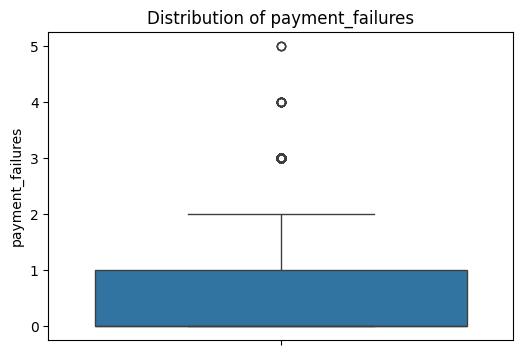

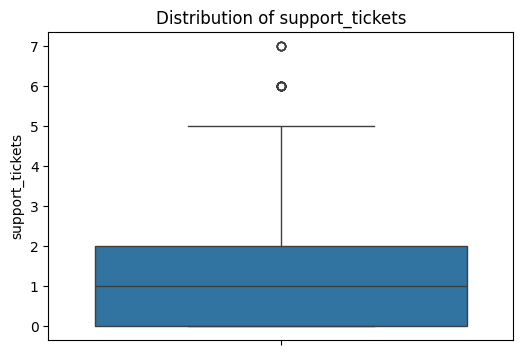

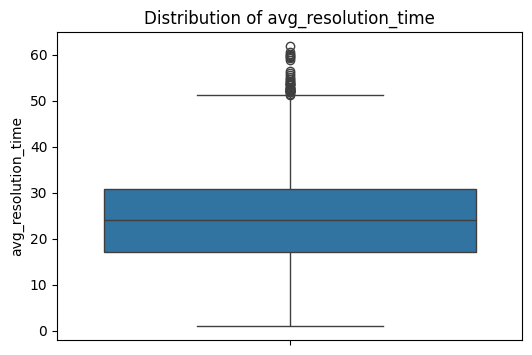

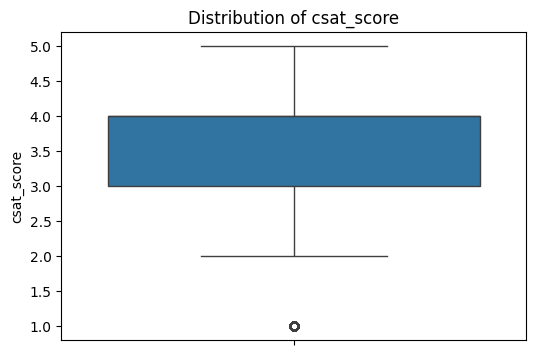

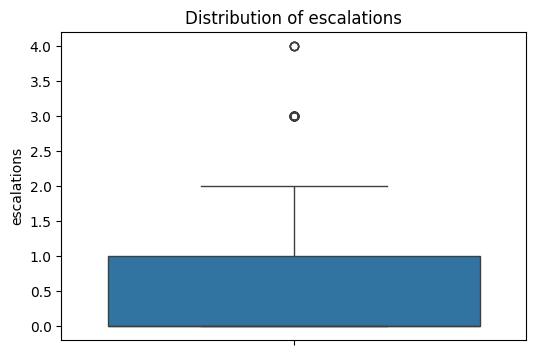

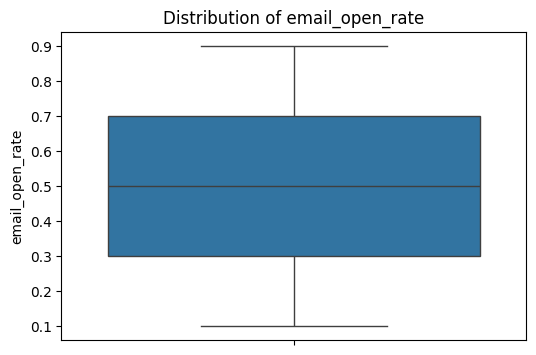

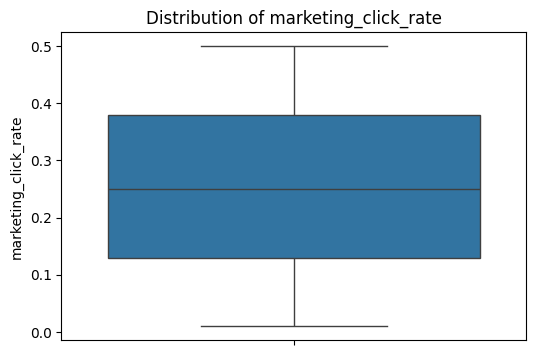

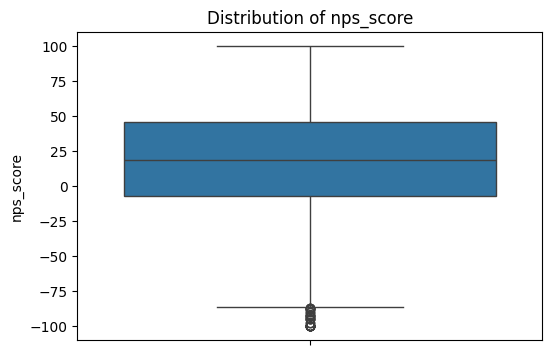

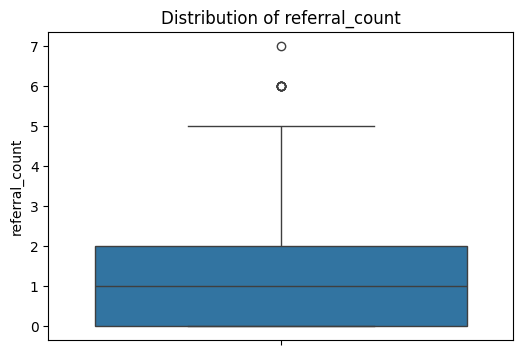

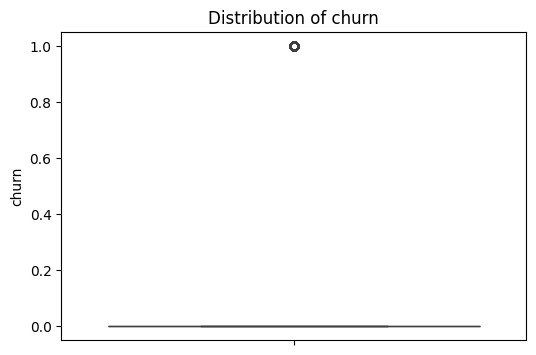

In [24]:
#Cek Outlier
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns


for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(df[col])
    plt.title(f'Distribution of {col}')
    plt.show()

In [25]:
cols = [
    "referral_count",
    "churn",
    "escalations"
]

for col in cols:
    print(col)
    print(df[col].unique())
    print()

referral_count
[1 2 0 3 5 4 6 7]

churn
[0 1]

escalations
[0 1 2 3 4]



In [28]:
num_cols = df.select_dtypes(include=np.number)

for col in num_cols:
    if np.isinf(num_cols[col]).any():
        print(f"{col} contains inf")

    if num_cols[col].isna().any():
        print(f"{col} contains NaN")

nps_score contains inf
nps_score contains NaN


In [29]:
df["nps_score"] = df["nps_score"].fillna(df["nps_score"].median(replace=True))

In [50]:
# Handling outlier

numerical_cols = numerical_cols.drop([
    "referral_count",
    "churn",
    "escalations"
], errors ="ignore")
for col in numerical_cols:
    df["total_revenue"] = np.log1p(df["total_revenue"])
    lower = df[col].quantile(0.05)
    upper = df[col].quantile(0.90)

    df[col] = df[col].clip(lower, upper)


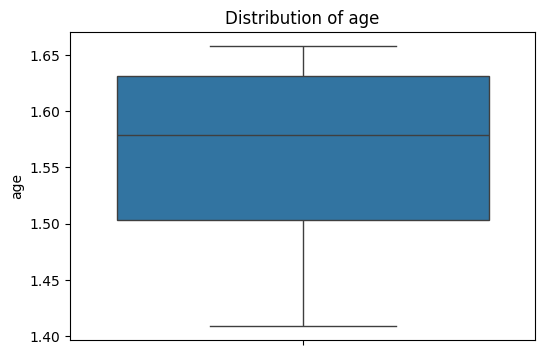

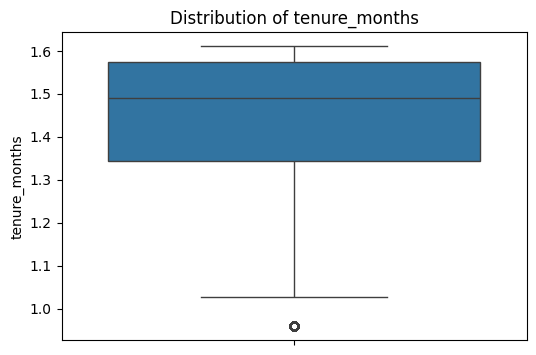

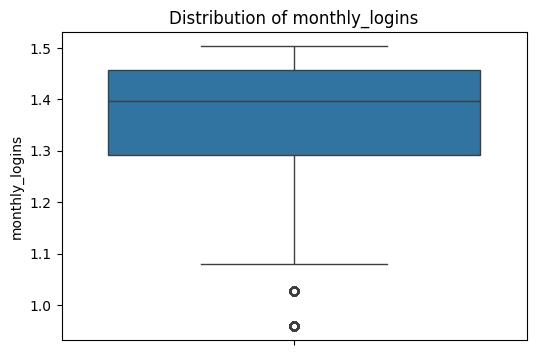

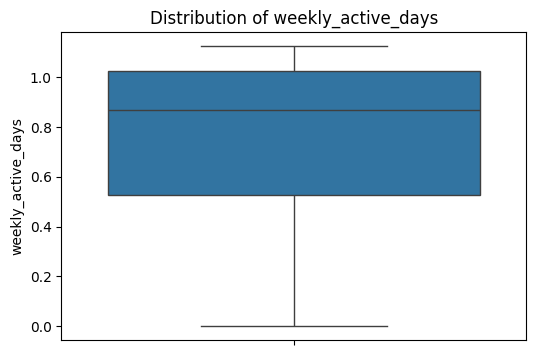

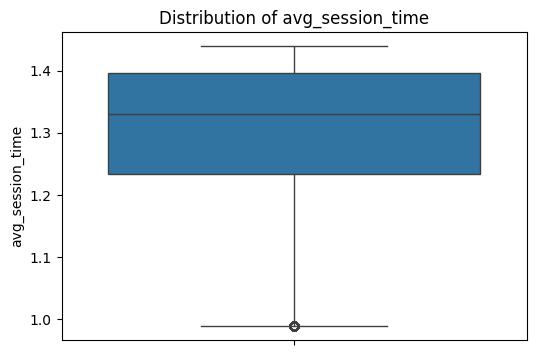

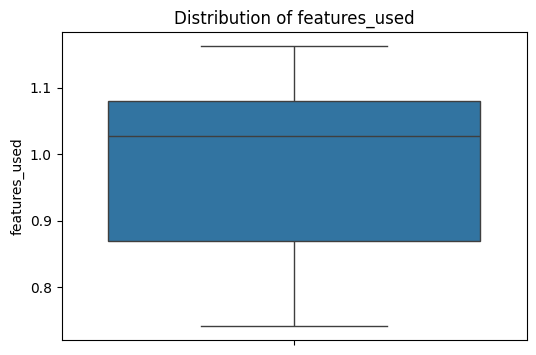

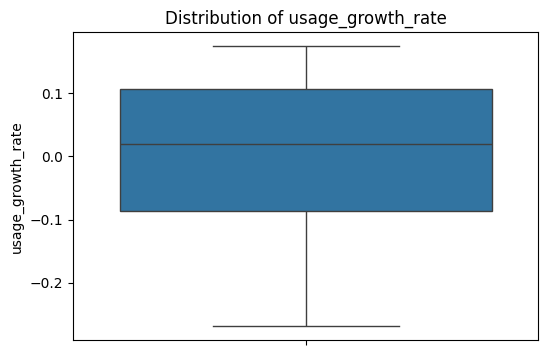

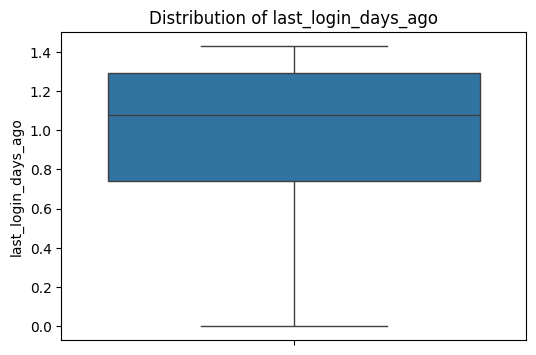

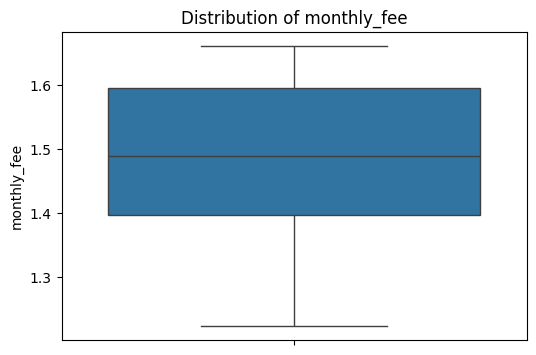

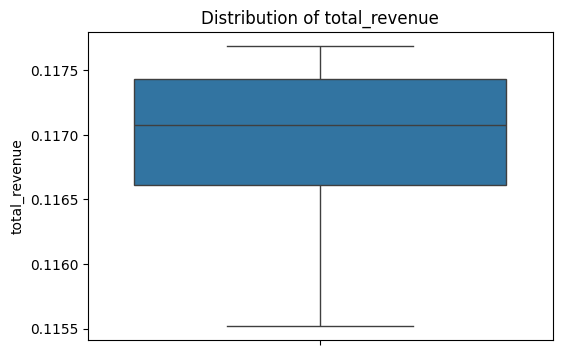

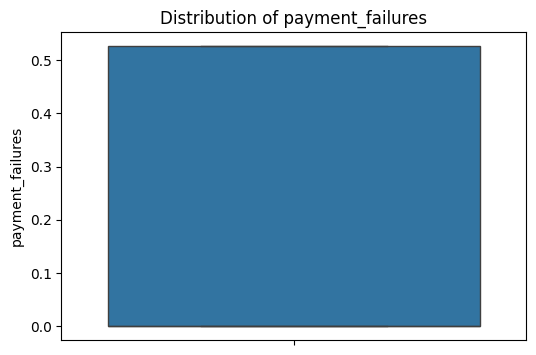

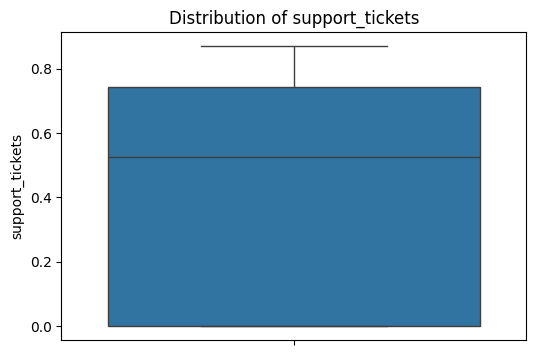

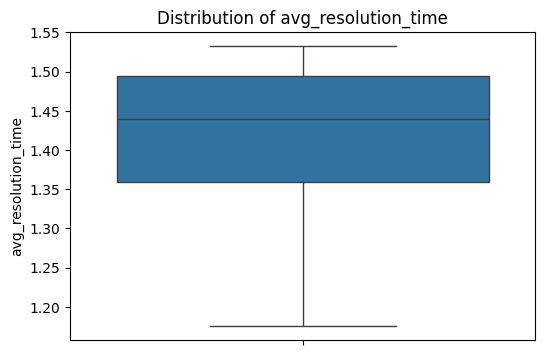

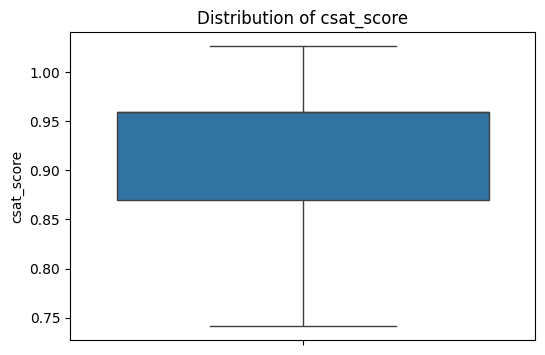

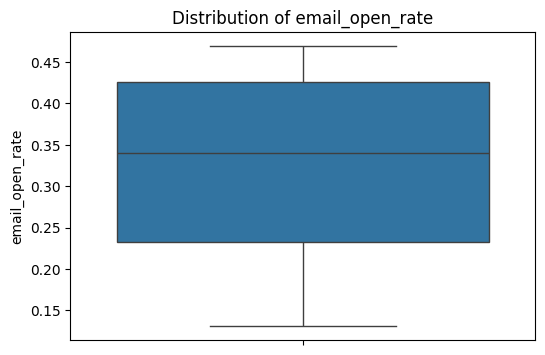

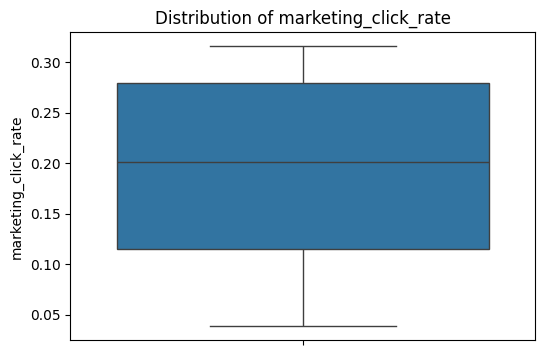

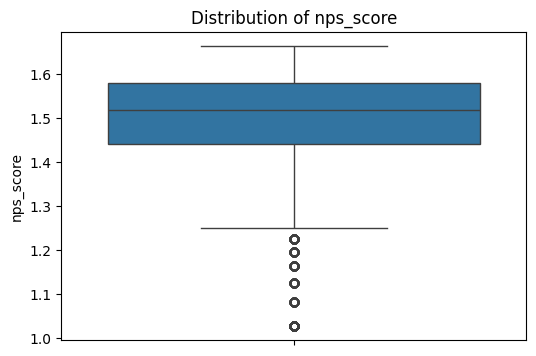

In [51]:
#Cek Outlier

for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(df[col])
    plt.title(f'Distribution of {col}')
    plt.show()

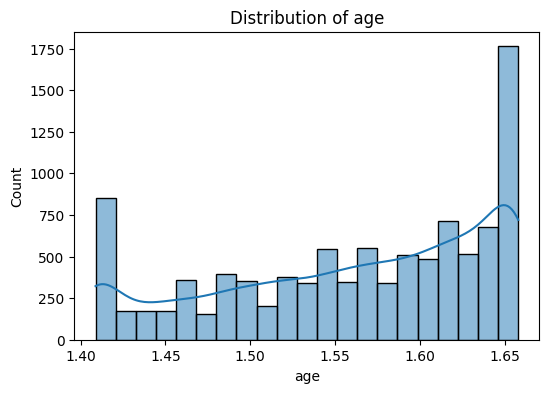

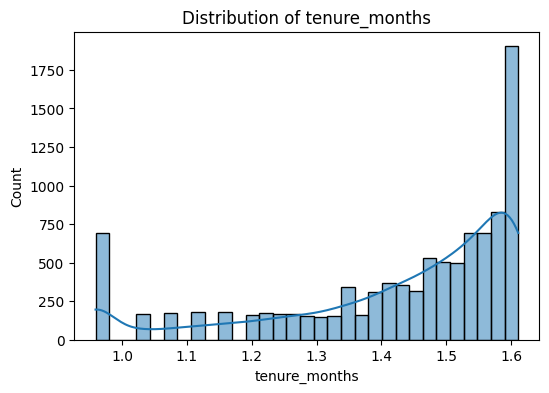

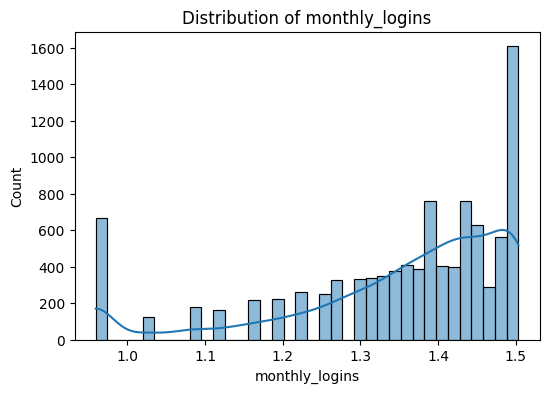

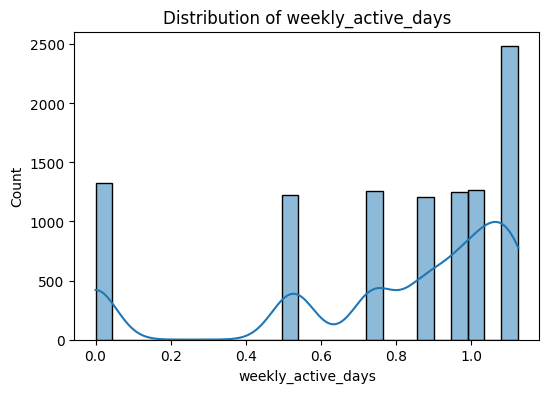

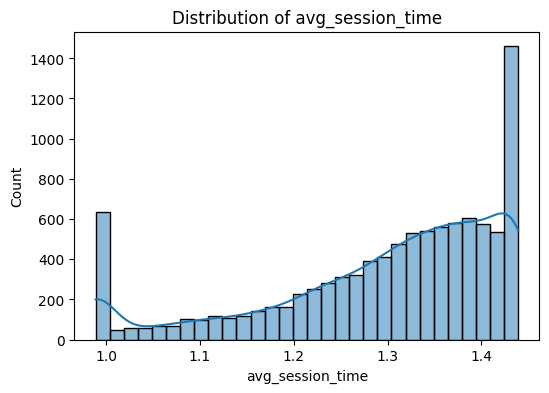

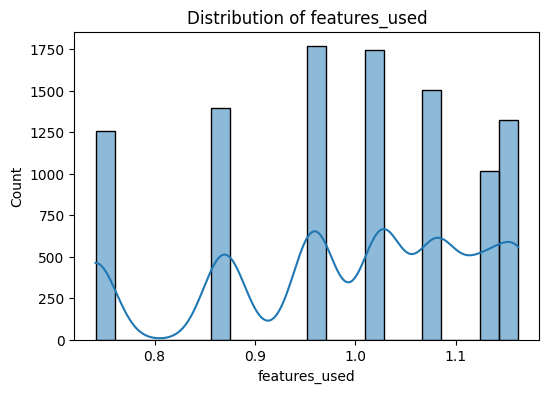

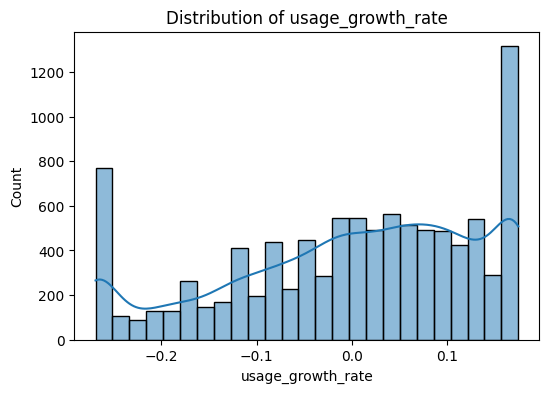

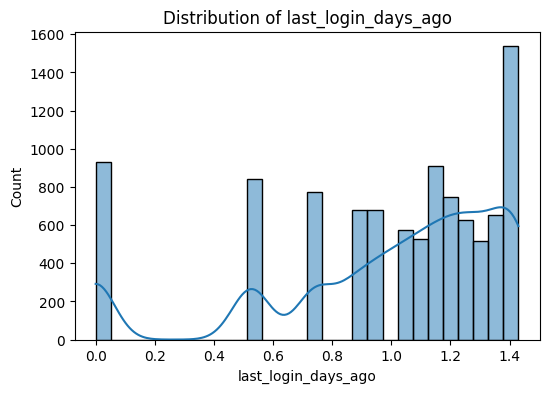

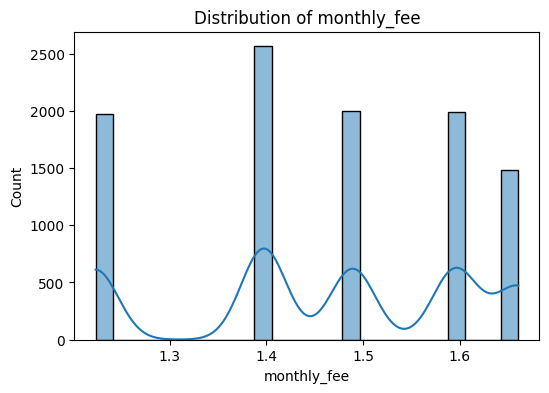

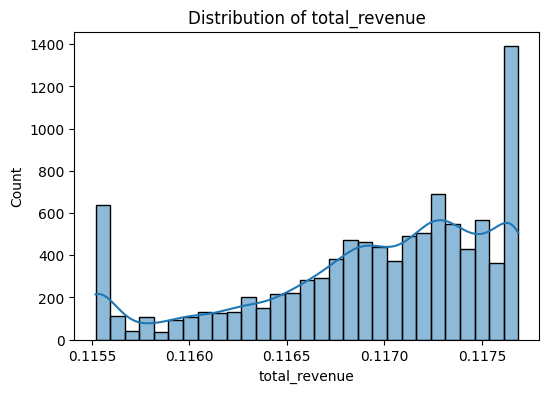

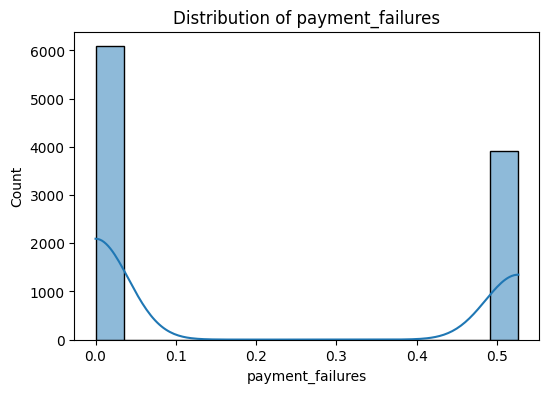

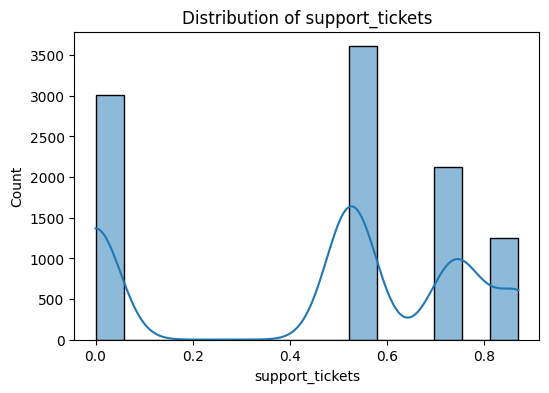

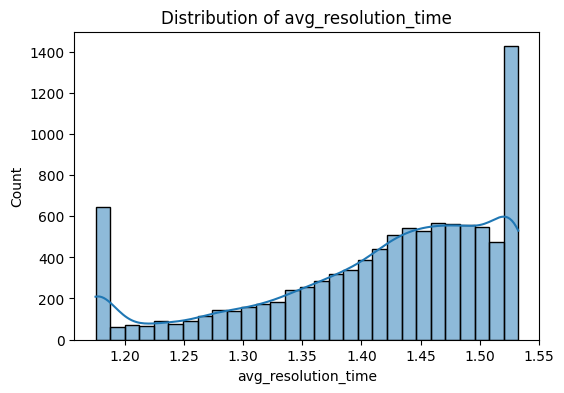

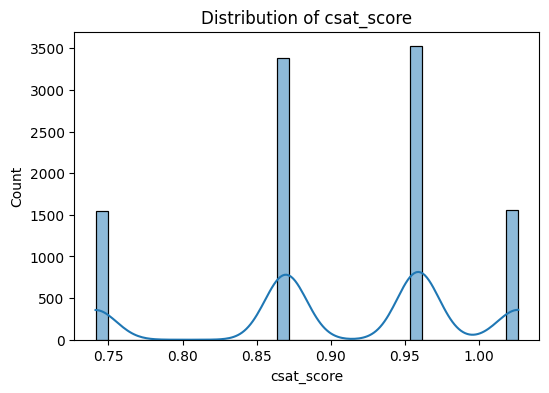

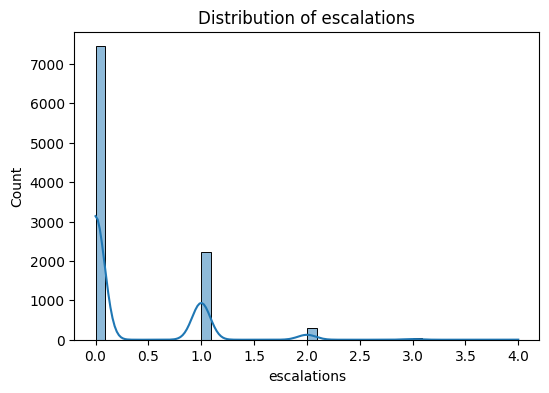

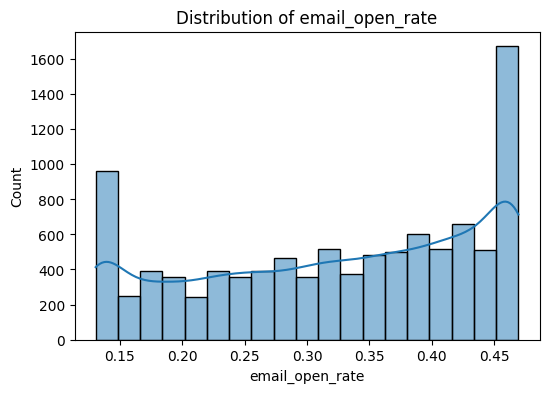

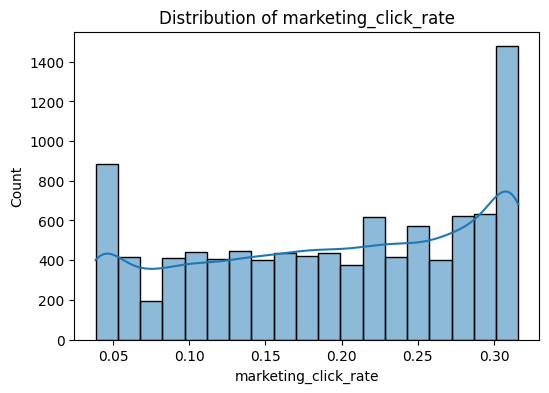

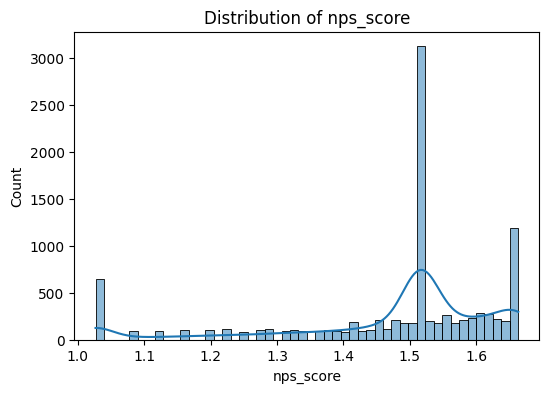

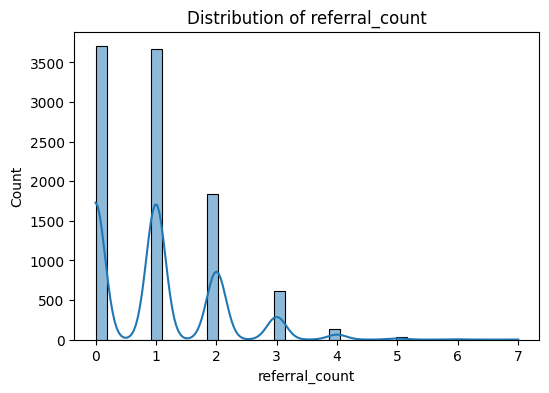

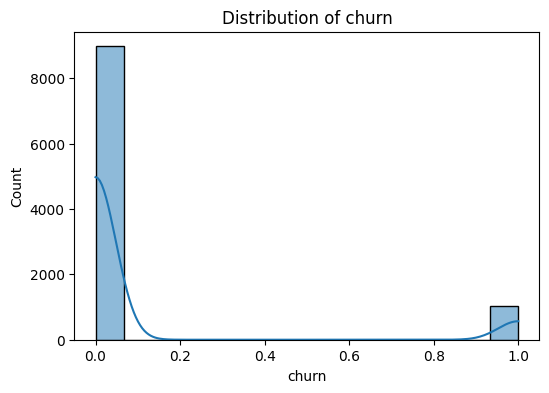

In [52]:
# Cek Sebaran Data

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

In [282]:
importance = best_model.named_steps['model'].feature_importances_

feature_names = best_model.named_steps[
    'preprocessing'
].get_feature_names_out()

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importance
})

importance_df.sort_values(
    by='importance',
    ascending=False
).head(15)

,feature,importance
0,num__csat_score,0.228250
1,num__payment_failures,0.141327
2,num__tenure_months,0.054313
4,num__monthly_logins,0.049294
16,cat__contract_type_monthly,0.047101
9,cat__survey_response_unsatisfied,0.046881
21,cat__customer_segment_sme,0.039876
19,cat__customer_segment_enterprise,0.037431
12,cat__complaint_type_technical,0.035997
3,num__total_revenue,0.032808


In [303]:
# feature Engineering
fitur_pilihan = [

    "csat_score",
    "payment_failures",
    "tenure_months",
    "monthly_logins",
    "total_revenue",

    "discount_applied",

    "survey_response",
    "complaint_type",
    "signup_channel",
    "contract_type",
    "customer_segment",

    "nps_score",
    "escalations",
    "avg_resolution_time"
]

X = df[fitur_pilihan]
y = df["churn"]

print(X.head())
print(y.head())

   csat_score  payment_failures  tenure_months  monthly_logins  total_revenue  \
0    0.959135          0.526589       1.419607        1.457646       0.117027   
1    0.741276          0.526589       1.194706        1.124748       0.116455   
2    0.869742          0.526589       1.610903        1.385227       0.117329   
3    1.026672          0.000000       1.385227        1.503301       0.116942   
4    0.959135          0.000000       1.603479        1.397363       0.117687   

  discount_applied survey_response complaint_type signup_channel  \
0              Yes       satisfied        service            web   
1               No         neutral        billing         mobile   
2               No         neutral        service            web   
3              Yes         neutral      technical         mobile   
4               No     unsatisfied      technical            web   

  contract_type customer_segment  nps_score  escalations  avg_resolution_time  
0       monthly         

In [304]:
from sklearn.model_selection import train_test_split
X = df[fitur_pilihan]
y = df["churn"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [305]:
print(X.head())
print(y.head())

   csat_score  payment_failures  tenure_months  monthly_logins  total_revenue  \
0    0.959135          0.526589       1.419607        1.457646       0.117027   
1    0.741276          0.526589       1.194706        1.124748       0.116455   
2    0.869742          0.526589       1.610903        1.385227       0.117329   
3    1.026672          0.000000       1.385227        1.503301       0.116942   
4    0.959135          0.000000       1.603479        1.397363       0.117687   

  discount_applied survey_response complaint_type signup_channel  \
0              Yes       satisfied        service            web   
1               No         neutral        billing         mobile   
2               No         neutral        service            web   
3              Yes         neutral      technical         mobile   
4               No     unsatisfied      technical            web   

  contract_type customer_segment  nps_score  escalations  avg_resolution_time  
0       monthly         

In [349]:
#import Library

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    OneHotEncoder,
    RobustScaler
)

from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import mutual_info_classif

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from imblearn.under_sampling import RandomUnderSampler



In [350]:
y.value_counts()

,count
churn,
0,8979
1,1021


In [351]:
# NUMERIC & CATEGORICAL COLUMNS
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(exclude=['int64', 'float64']).columns.tolist()


In [309]:
# NUMERIC PIPELINE
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

# CATEGORICAL PIPELINE
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])


In [310]:
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, num_cols),
    ("cat", categorical_pipeline, cat_cols)
])

In [359]:

# FULL PIPELINE

pipeline = ImbPipeline([
    ("preprocessing", preprocessor),
    ('model', XGBClassifier(scale_pos_weight=8.79, random_state=42))
])

pipeline.fit(X_train, y_train)

,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The giv

In [360]:

# Mendapatkan feature importance setelah training
feature_importance = pipeline.named_steps['model'].feature_importances_
print("\nFeature Importances:", feature_importance)


Feature Importances: [0.13027768 0.07363658 0.07215962 0.05268223 0.0373757  0.03179675
 0.02902135 0.03656858 0.02807134 0.         0.03420125 0.0372662
 0.04081997 0.02601339 0.03125172 0.03647692 0.03109949 0.03562765
 0.03378132 0.02839869 0.0409082  0.0328651  0.02900829 0.03479855
 0.0358934 ]


In [361]:
feature_names = X.columns

# Ambil nilai feature importance
feature_importance = pipeline.named_steps['model'].feature_importances_

#nama fitur + importance
for name, importance in zip(feature_names, feature_importance):
    print(f"{name}: {importance}")

csat_score: 0.13027767837047577
payment_failures: 0.07363658398389816
tenure_months: 0.07215961813926697
monthly_logins: 0.05268223211169243
total_revenue: 0.03737570345401764
discount_applied: 0.03179675340652466
survey_response: 0.029021350666880608
complaint_type: 0.03656857833266258
signup_channel: 0.028071340173482895
contract_type: 0.0
customer_segment: 0.034201253205537796
nps_score: 0.03726620227098465
escalations: 0.04081996530294418
avg_resolution_time: 0.026013392955064774


In [362]:
y_pred = pipeline.predict(X_test)

In [363]:
accuracy_score = pipeline.score(X_test, y_test)
print(f"Akurasi: {accuracy_score}")

Akurasi: 0.8445


In [364]:
from sklearn.metrics import classification_report

# classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.92      0.91      1780
           1       0.25      0.20      0.22       220

    accuracy                           0.84      2000
   macro avg       0.58      0.56      0.57      2000
weighted avg       0.83      0.84      0.84      2000



In [365]:
# cek apakah model overfitting / underfitting

train_score = pipeline.score(X_train, y_train)
test_score = pipeline.score(X_test, y_test)

print("Train Score :", train_score)
print("Test Score  :", test_score)

Train Score : 0.994375
Test Score  : 0.8445


In [366]:

param_grid = {

     'model__n_estimators': [100, 150],

    'model__max_depth': [3, 4],

    'model__learning_rate': [0.05, 0.1],

    'model__scale_pos_weight': [8.79]
}



grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=2
)

In [367]:
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__learning_rate': [0.05, 0.1], 'model__max_depth': [3, 4], 'model__n_estimators': [100, 150], 'model__scale_pos_weight': [8.79]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold

In [368]:
#Hasil setelah GridSearch

from sklearn.metrics import f1_score

best_model = grid_search.best_estimator_

print("Train:", f1_score(y_train, best_model.predict(X_train)))
print("Test :", f1_score(y_test, best_model.predict(X_test)))

Train: 0.38981390793339865
Test : 0.3772609819121447


In [369]:
!pip install optuna

In [370]:
#menggunakan optuna
import optuna
from sklearn.model_selection import cross_val_score
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline

def objective(trial):

    params = {

     "n_estimators": trial.suggest_int("n_estimators", 100, 300),

    "max_depth": trial.suggest_int("max_depth", 3, 5),

    "learning_rate": trial.suggest_float(
        "learning_rate", 0.05, 0.2
    ),

    "subsample": trial.suggest_float("subsample", 0.8, 1.0),

    "colsample_bytree": trial.suggest_float(
        "colsample_bytree", 0.8, 1.0
    ),

    "gamma": trial.suggest_float("gamma", 0, 0.1),

    "reg_alpha": trial.suggest_float("reg_alpha", 0, 0.3),

    "reg_lambda": trial.suggest_float("reg_lambda", 1, 3),

    "scale_pos_weight": 5,

    "tree_method": "hist",
    "eval_metric": "logloss",
    "random_state": 42,
    "n_jobs": 1

    }

    model = XGBClassifier(**params)

    pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ('model', model)
    ])

    score = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=3,
        scoring='f1',
        n_jobs=-1
    ).mean()

    return score

In [373]:
#menjalankan optuna
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=60)

[I 2026-05-16 09:05:39,520] A new study created in memory with name: no-name-9530f097-5535-4b4f-ad9a-cfe72f4648ba
[I 2026-05-16 09:05:40,687] Trial 0 finished with value: 0.3489349447123773 and parameters: {'n_estimators': 120, 'max_depth': 3, 'learning_rate': 0.19722488605779792, 'subsample': 0.8983924510455591, 'colsample_bytree': 0.9793105338778118, 'gamma': 0.05292846347488124, 'reg_alpha': 0.08480774691829851, 'reg_lambda': 2.9453960521840736}. Best is trial 0 with value: 0.3489349447123773.
[I 2026-05-16 09:05:43,644] Trial 1 finished with value: 0.3224385066163812 and parameters: {'n_estimators': 255, 'max_depth': 4, 'learning_rate': 0.09034791126263879, 'subsample': 0.8900636052404554, 'colsample_bytree': 0.9914295588857996, 'gamma': 0.014342575396748648, 'reg_alpha': 0.24320749519048487, 'reg_lambda': 1.0623835343431012}. Best is trial 0 with value: 0.3489349447123773.
[I 2026-05-16 09:05:45,789] Trial 2 finished with value: 0.33773870076579265 and parameters: {'n_estimators':

In [374]:
#Hasil optuna
print(study.best_value)
print(study.best_params)

0.36333820027614916
{'n_estimators': 259, 'max_depth': 3, 'learning_rate': 0.05728832292689755, 'subsample': 0.8413898062464354, 'colsample_bytree': 0.886833029497554, 'gamma': 0.05757482030475907, 'reg_alpha': 0.23617547537506509, 'reg_lambda': 1.714428496608554}


In [376]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.92      0.91      1780
           1       0.25      0.20      0.22       220

    accuracy                           0.84      2000
   macro avg       0.58      0.56      0.57      2000
weighted avg       0.83      0.84      0.84      2000



In [378]:
from sklearn.metrics import classification_report

y_prob = pipeline.predict_proba(X_test)[:,1]

y_pred = (y_prob >= 0.35).astype(int)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.87      0.89      1780
           1       0.21      0.29      0.24       220

    accuracy                           0.80      2000
   macro avg       0.56      0.58      0.56      2000
weighted avg       0.83      0.80      0.82      2000



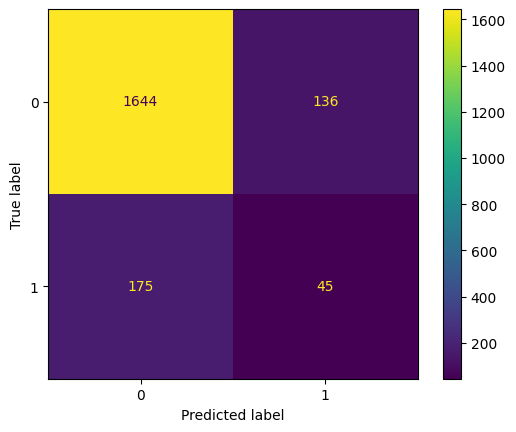

In [379]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(pipeline, X_test, y_test)
plt.show()

In [380]:
# Save Moddel
import joblib

joblib.dump(pipeline, 'model_churn.pkl')

['model_churn.pkl']